## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [2]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')

## Define config

In [3]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

LAM_ISOS = [
    'ABW', 'ARG', 'ATG', 'BHS', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'CHL', 'COL',
    'CRI', 'CUB', 'CYM', 'DMA', 'DOM', 'ECU', 'FLK', 'GLP', 'GRD', 'GTM', 'GUF',
    'GUY', 'HND', 'HTI', 'JAM', 'KNA', 'LCA', 'MEX', 'MSR', 'MTQ','NIC', 'PAN', 'PER',
    'PRI', 'PRY', 'SLV', 'SUR', 'TCA', 'TTO', 'URY', 'VCT', 'VEN', 'VGB', 'VIR']

IKEA_ISOS.sort()

In [4]:
dscale_project = 'REMIND_Q1_2026'
dscale_suffix = '05_03_2026'

## Load data

In [5]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [6]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [7]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [8]:
NPE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Country assessment"

)

NPE_PATH: os.PathLike = BOX_MOUNT_PATH / NPE_PATH

Load up the input data

In [9]:
input_data = pyam.IamDataFrame(
    f'../input_data/{dscale_project}/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file ../input_data/REMIND_Q1_2026/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv


Load up historical data

In [10]:
hist_data_iea = pyam.IamDataFrame('../input_data/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file ../input_data/input_reference_iea_2022.csv


Load up SIAMESE data for comparison with old results

In [11]:
npe_siamese = pyam.IamDataFrame(NPE_PATH / '3_Data/results_v12/siamese.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Country assessment/3_Data/results_v12/siamese.csv


Load up DSCALE results

In [12]:
dscale_results = pyam.IamDataFrame(f'../results/5_Explorer_and_New_Variables/{dscale_project}/{dscale_suffix}/REMIND 3.4_2023_harmo_step5h_hydrogen.csv')
# dscale_results = pyam.IamDataFrame(f'../results/5_Explorer_and_New_Variables/{dscale_project}/{dscale_suffix}/REMIND 3.4_2022_harmo_step5e_None.csv')

pyam.core - INFO: Reading file ../results/5_Explorer_and_New_Variables/REMIND_Q1_2026/05_03_2026/REMIND 3.4_2023_harmo_step5h_hydrogen.csv


In [13]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [14]:
dscale_results_agg = pyam.IamDataFrame(create_macro_df(dscale_results).timeseries())
hist_agg = pyam.IamDataFrame(create_macro_df(hist_data_iea).timeseries())

# PLOTTING DATA

In [13]:
from typing import Union, List, Iterable

def final_energy(
    sector: Union[str, Iterable[str], None] = None,
    fuel: Union[str, Iterable[str], None] = None
) -> Union[str, List[str]]:
    """
    Build Final Energy IAM variable strings.

    Supports single or multiple sectors and/or fuels.

    Parameters
    ----------
    sector : str or list[str], optional
        Sector(s), e.g. 'Industry', ['Industry', 'Transportation']
    fuel : str or list[str], optional
        Fuel(s), e.g. 'Liquids', ['Liquids', 'Gases', '*']

    Returns
    -------
    str or list[str]
        IAM variable string(s)
    """

    base = "Final Energy"

    # Normalize to lists
    sectors = [sector] if isinstance(sector, str) else sector
    fuels = [fuel] if isinstance(fuel, str) else fuel

    # Case 1: no sector, no fuel
    if sectors is None and fuels is None:
        return f"{base}|"

    results = []

    # Case 2: fuel only
    if sectors is None:
        for f in fuels:
            results.append(f"{base}|{f}")

    # Case 3: sector only
    elif fuels is None:
        for s in sectors:
            results.append(f"{base}|{s}")

    # Case 4: sector + fuel (cartesian product)
    else:
        for s in sectors:
            for f in fuels:
                results.append(f"{base}|{s}|{f}")

    return results[0] if len(results) == 1 else results

## First, regional consistency check
Does the data add back up to the regional level?

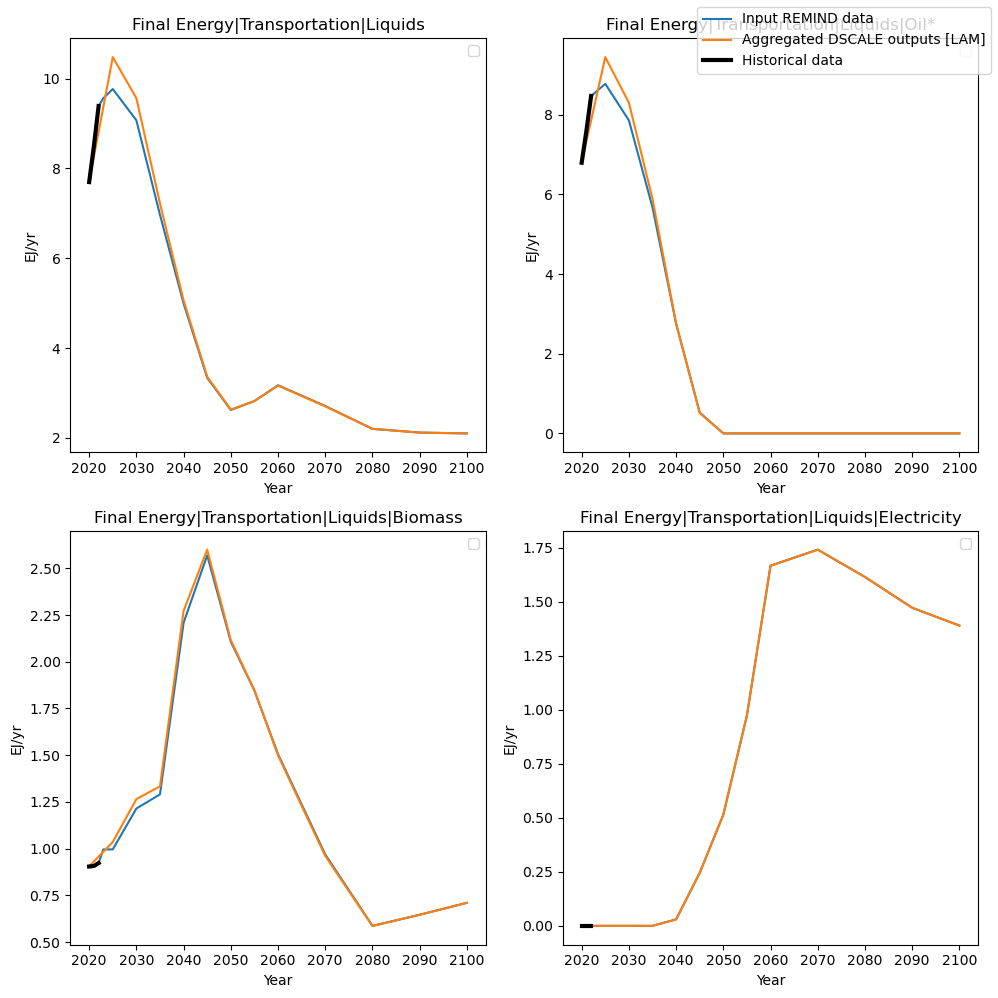

In [16]:
fuels = ['','|Oil*','|Biomass','|Electricity']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=2,nrows=2,figsize=(10,10))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2023)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

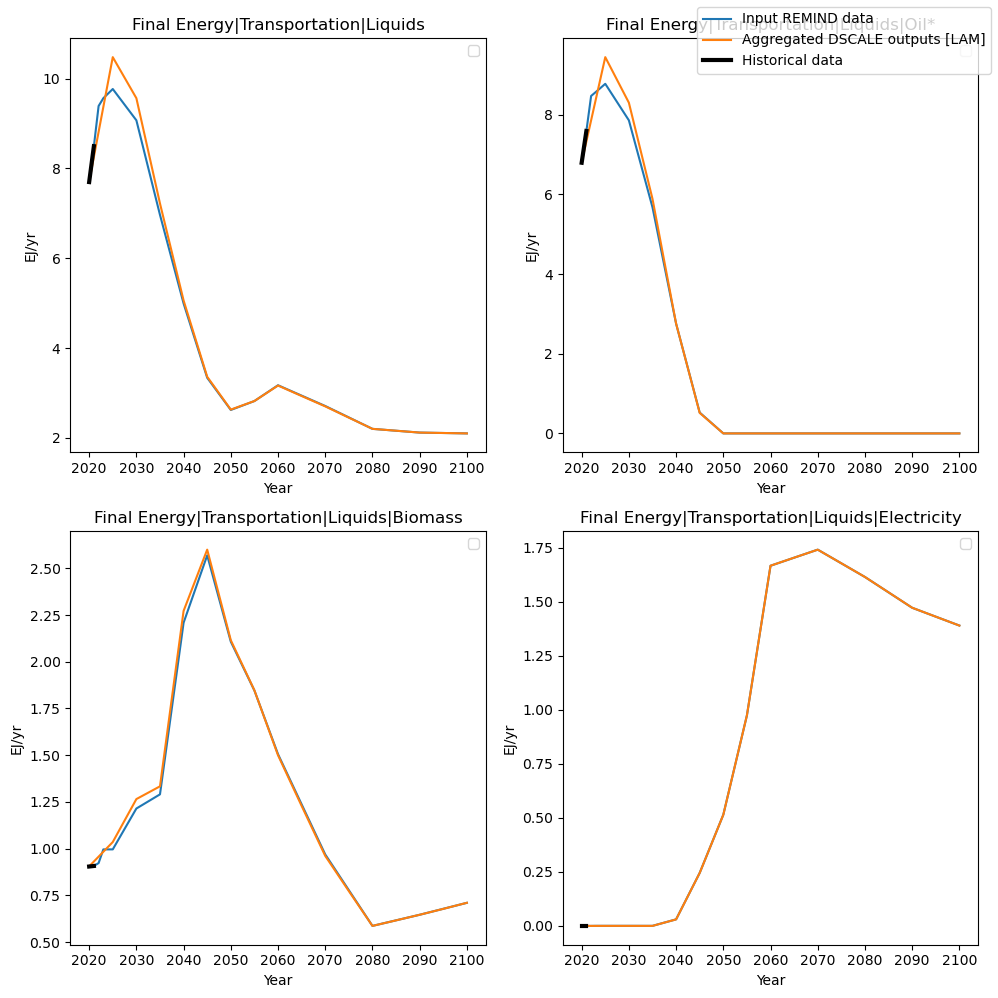

In [17]:
fuels = ['','|Oil*','|Biomass','|Electricity']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=2,nrows=2,figsize=(10,10))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2022)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

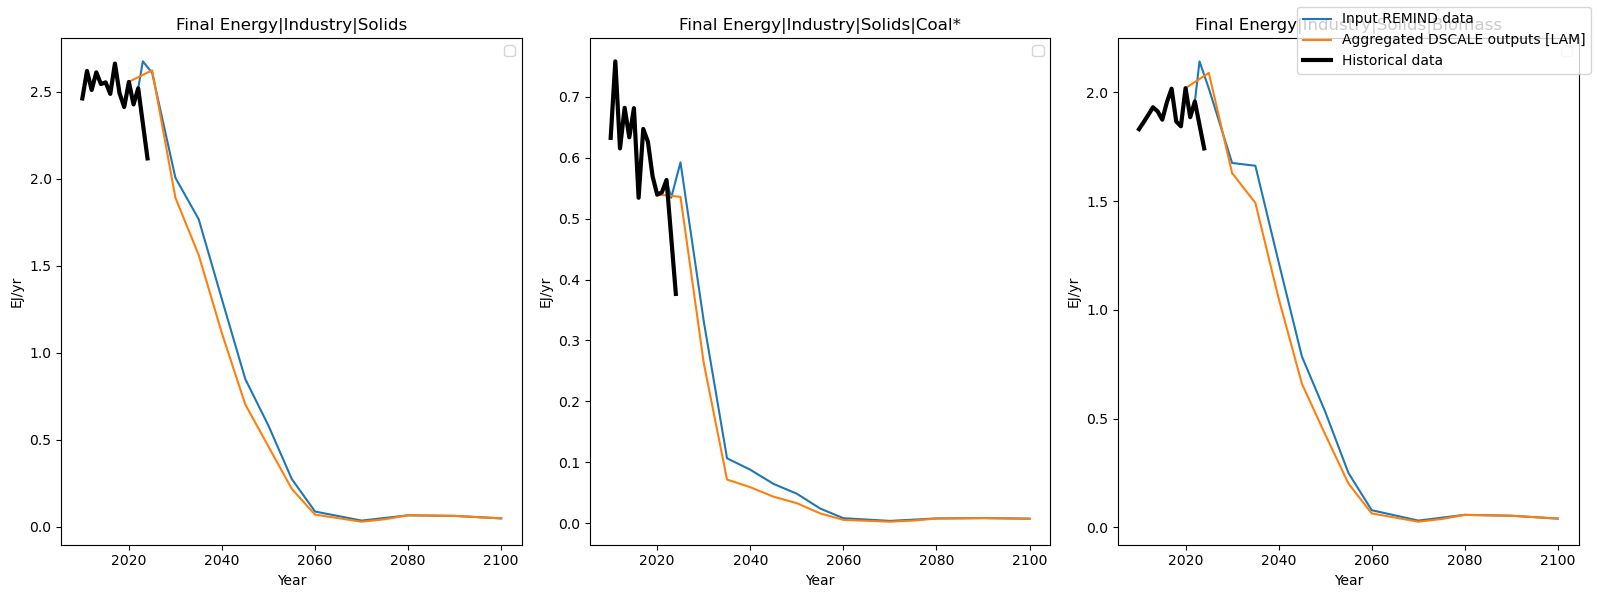

In [18]:
fuels = ['','|Coal*','|Biomass']
phase = 'Solids'
sector = 'Industry'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    # input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2010,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

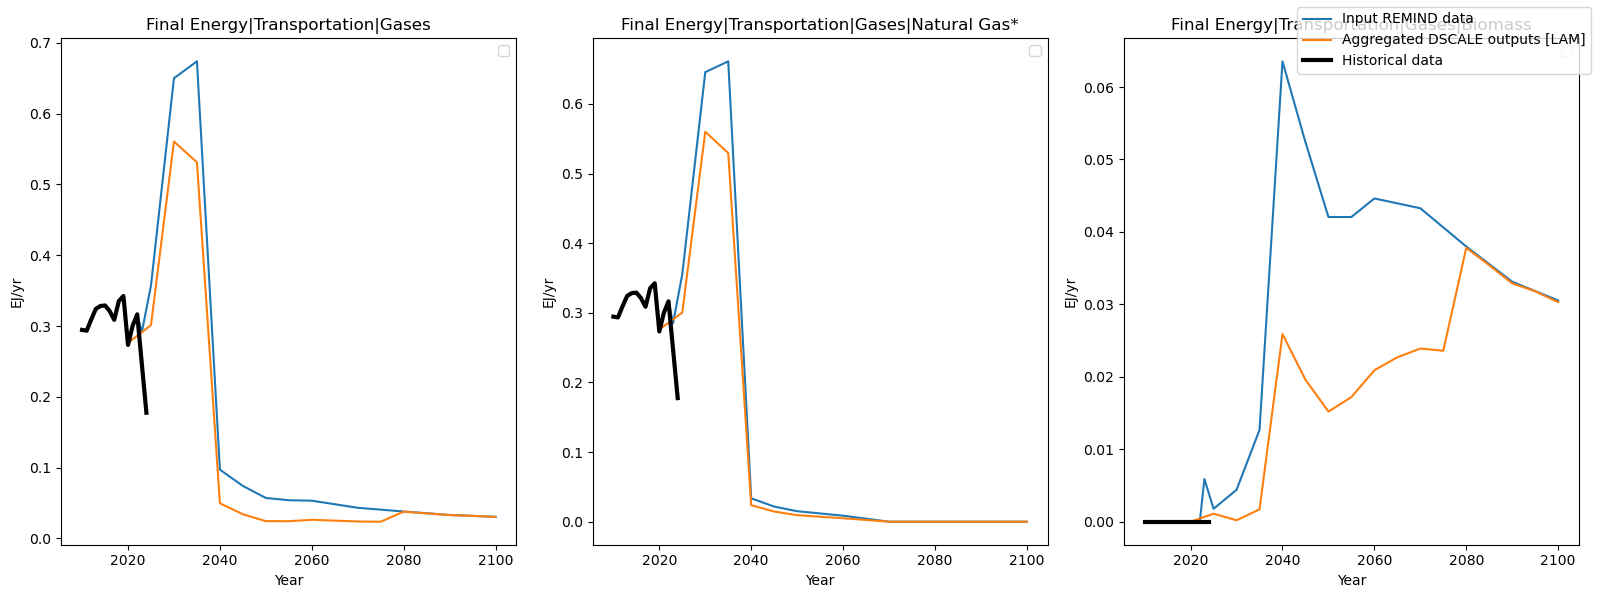

In [19]:
fuels = ['','|Natural Gas*','|Biomass']
phase = 'Gases'
sector = 'Transportation'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    # input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2010,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

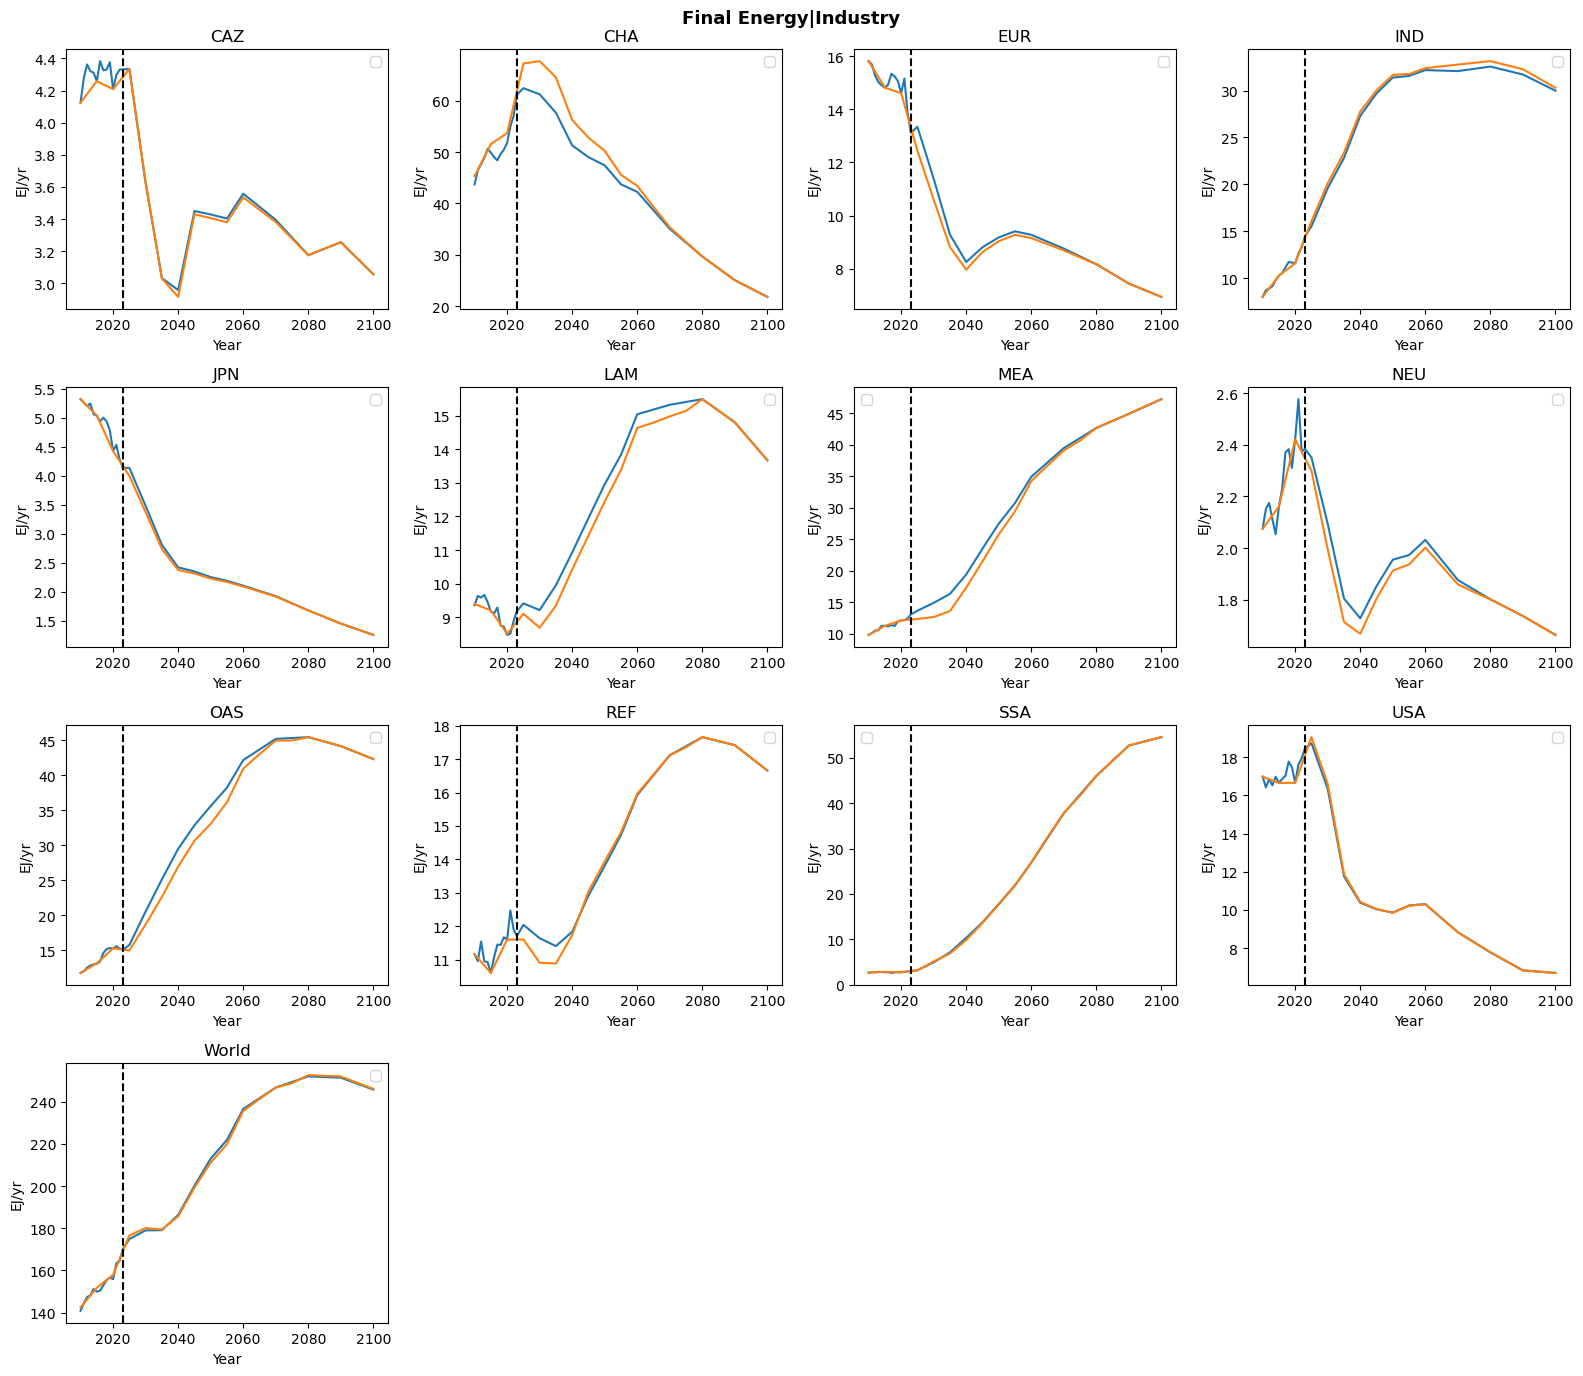

In [24]:
regions = sorted(dscale_results_agg.region)
plot_var = "Final Energy|Industry"
ncols = 4
nrows = (len(regions) + ncols - 1) // ncols

f, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 3.5))
shared_handles = None

for ax, plot_reg in zip(axes.ravel(), regions):
    input_data.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    dscale_results_agg.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(plot_reg)
    if shared_handles is None:
        shared_handles, _ = ax.get_legend_handles_labels()
    ax.legend([])

for ax in axes.ravel()[len(regions):]:
    ax.set_visible(False)

f.suptitle(plot_var, fontsize=13, fontweight='bold')
if shared_handles:
    f.legend(
        shared_handles,
        ['Input data', 'Re-aggregated downscaling'][:len(shared_handles)],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.01),
    )
plt.tight_layout()

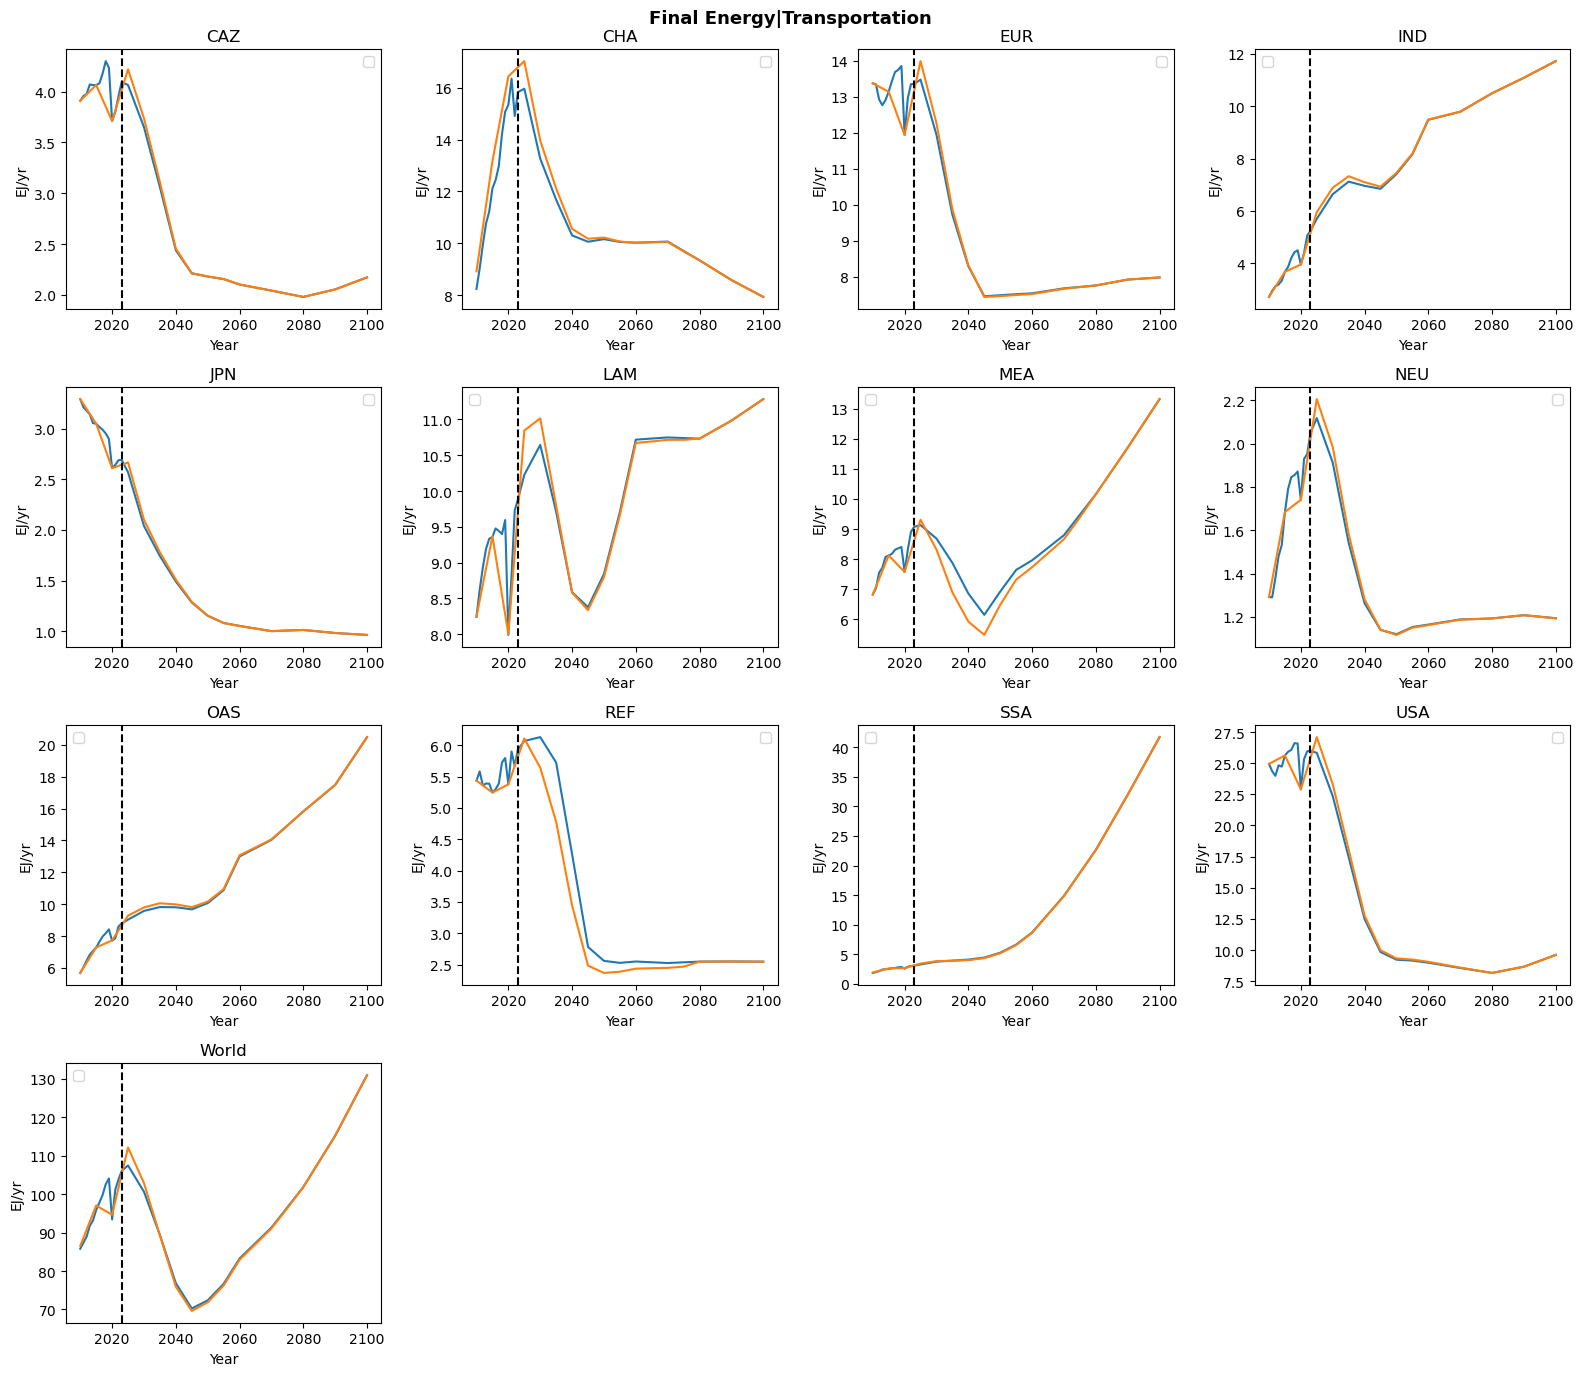

In [28]:
regions = sorted(dscale_results_agg.region)
plot_var = "Final Energy|Transportation"
ncols = 4
nrows = (len(regions) + ncols - 1) // ncols

f, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 3.5))
shared_handles = None

for ax, plot_reg in zip(axes.ravel(), regions):
    input_data.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    dscale_results_agg.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(plot_reg)
    if shared_handles is None:
        shared_handles, _ = ax.get_legend_handles_labels()
    ax.legend([])

for ax in axes.ravel()[len(regions):]:
    ax.set_visible(False)

f.suptitle(plot_var, fontsize=13, fontweight='bold')
if shared_handles:
    f.legend(
        shared_handles,
        ['Input data', 'Re-aggregated downscaling'][:len(shared_handles)],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.01),
    )
plt.tight_layout()

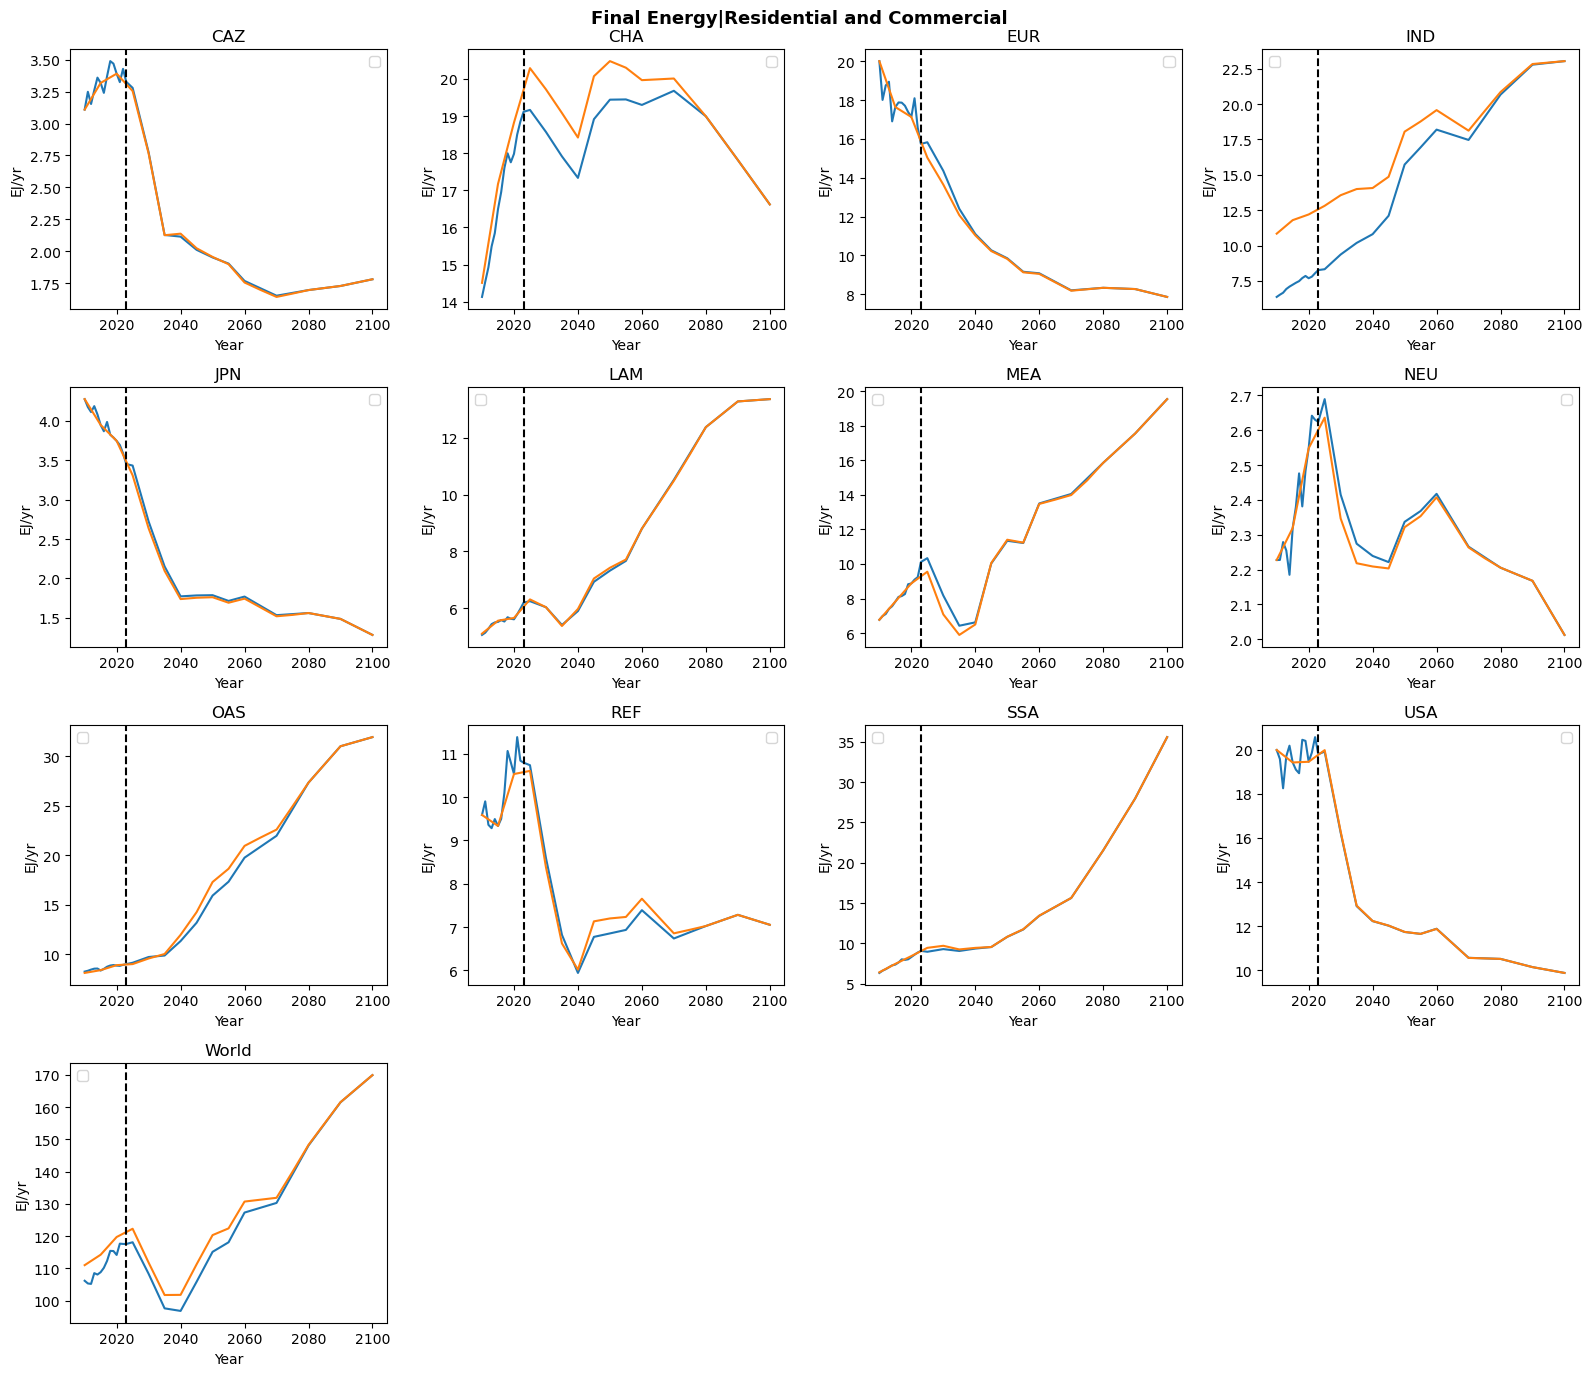

In [25]:
regions = sorted(dscale_results_agg.region)
plot_var = "Final Energy|Residential and Commercial"
ncols = 4
nrows = (len(regions) + ncols - 1) // ncols

f, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 3.5))
shared_handles = None

for ax, plot_reg in zip(axes.ravel(), regions):
    input_data.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    dscale_results_agg.filter(region=plot_reg, variable=plot_var, scenario='*core*').plot(ax=ax)
    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(plot_reg)
    if shared_handles is None:
        shared_handles, _ = ax.get_legend_handles_labels()
    ax.legend([])

for ax in axes.ravel()[len(regions):]:
    ax.set_visible(False)

f.suptitle(plot_var, fontsize=13, fontweight='bold')
if shared_handles:
    f.legend(
        shared_handles,
        ['Input data', 'Re-aggregated downscaling'][:len(shared_handles)],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.01),
    )
plt.tight_layout()

## Second – looking at inter-sector and cross-sector consistency
Do carriers add up to the total per sector? Do sectors add up to the total final energy?

In [37]:
def find_sector_aggregation_issues(sector, N=25, rtol=2.5e-2, atol=1e-3):
    """Find issues with sector aggregation
    
    Arguments:
    - sector: str: Choose sector for analysis
    - N=25: int: Number of problem sectors to highlight (the top N)
    - rtol: float: Relative tolerance for finding deviations, passed to numpy.isclose
    - atol: float: Absolute tolerance for finding deviations, passed to numpy.isclose
    
    
    """
    try: 
        component_df = dscale_results.filter(year=range(2035,2051)).check_aggregate(
                f'Final Energy|{sector}',
                [
                    f'Final Energy|{sector}|Liquids',
                    f'Final Energy|{sector}|Solids',
                    f'Final Energy|{sector}|Gases',
                    f'Final Energy|{sector}|Heat',
                    f'Final Energy|{sector}|Hydrogen',
                    f'Final Energy|{sector}|Electricity',
                ], rtol=rtol, atol=atol
            )
        
        problem_results = (component_df/component_df.shift(axis=1) - 1).abs().sort_values('components').loc[isin(region=IKEA_ISOS)].tail(N).index

        return component_df.loc[problem_results].sort_index()

    except: 
        return("Components are all summing up to the total")

    

In [38]:
find_sector_aggregation_issues('Transportation')

'Components are all summing up to the total'

In [39]:
find_sector_aggregation_issues('Industry')

'Components are all summing up to the total'

In [40]:
find_sector_aggregation_issues('Residential and Commercial')

'Components are all summing up to the total'

In [41]:
def find_carrier_aggregation_issues(carrier, N=25, rtol=5e-2, atol=1e-3):
    """Find issues with carrier aggregation
    
    Arguments:
    - carrier: str: Choose carrier for analysis
    - N=25: int: Number of problem carrier to highlight (the top N)
    - rtol: float: Relative tolerance for finding deviations, passed to numpy.isclose
    - atol: float: Absolute tolerance for finding deviations, passed to numpy.isclose
    
    
    """
    try:
        component_df = dscale_results.filter(year=range(2035,2051)).check_aggregate(
                f'Final Energy|{carrier}',
                [
                    f'Final Energy|Residential and Commercial|{carrier}',
                    f'Final Energy|Transportation|{carrier}',
                    f'Final Energy|Industry|{carrier}',
                ], rtol=rtol, atol=atol
            )
        
        problem_results = (component_df/component_df.shift(axis=1) - 1).abs().sort_values('components').loc[isin(region=IKEA_ISOS)].tail(N).index

        return component_df.loc[problem_results]
    
    except: 
        return("Components are all summing up to the total")


    

In [42]:
find_carrier_aggregation_issues('Electricity')

'Components are all summing up to the total'

In [43]:
find_carrier_aggregation_issues('Liquids')

'Components are all summing up to the total'

Look at whether Sum(sectors) = Final Energy

In [44]:
missing_final_energy = (
    dscale_results_agg
    .filter(variable=['Final Energy','Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial'])
    .check_aggregate(
        'Final Energy',
        ['Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial']
    ).diff(axis=1)
)

NameError: name 'dscale_results_agg' is not defined

In [162]:
inferred_other_sector = (missing_final_energy.components*-1).unstack('year').pix.assign(variable='Final Energy|Other Sector')

In [163]:
inferred_other_sector

year                                                            2025  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.001408   
                    OAS    Final Energy|Other Sector EJ/yr  0.001408   
                    SSA    Final Energy|Other Sector EJ/yr  0.001408   
                    World  Final Energy|Other Sector EJ/yr  0.004224   

year                                                            2030  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.036331   
                    OAS    Final Energy|Other Sector EJ/yr  0.003131   
                    SSA    Final Energy|Other Sector EJ/yr  0.009180   
                    World  Final Energy|Other Sector EJ/yr  0.048642   

year                                                            2035  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.168645   
                    OAS    Final Energy|Other Sector EJ/yr  0.023063   
                    SSA    Final Energy|Other Sector EJ/yr  0.045184   
                    World  Final Energy|Other Sector EJ/yr  0.236892   

year                                                            2040  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.471050   
                    OAS    Final Energy|Other Sector EJ/yr  0.097358   
                    SSA    Final Energy|Other Sector EJ/yr  0.158717   
                    World  Final Energy|Other Sector EJ/yr  0.727125   

year                                                            2045  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.840695   
                    OAS    Final Energy|Other Sector EJ/yr  0.296428   
                    SSA    Final Energy|Other Sector EJ/yr  0.444684   
                    World  Final Energy|Other Sector EJ/yr  1.581808   

year                                                            2050  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.954406   
                    OAS    Final Energy|Other Sector EJ/yr  0.745090   
                    SSA    Final Energy|Other Sector EJ/yr  1.012689   
                    World  Final Energy|Other Sector EJ/yr  2.712184   

year                                                            2055  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.948447   
                    OAS    Final Energy|Other Sector EJ/yr  1.660412   
                    SSA    Final Energy|Other Sector EJ/yr  1.863317   
                    World  Final Energy|Other Sector EJ/yr  4.472175   

year                                                            2060  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  0.963586   
                    OAS    Final Energy|Other Sector EJ/yr  3.885551   
                    SSA    Final Energy|Other Sector EJ/yr  3.312871   
                    World  Final Energy|Other Sector EJ/yr  8.162008   

year                                                             2065  \
model      scenario region variable                  unit               
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr   0.957945   
                    OAS    Final Energy|Other Sector EJ/yr   5.850464   
                    SSA    Final Energy|Other Sector EJ/yr   4.021150   
                    World  Final Energy|Other Sector EJ/yr  10.829558   

year                                                             2070  \
model      scenario regi

In [164]:
(
    inferred_other_sector / 
    input_data.filter(variable='Final Energy|Other Sector').timeseries()
).interpolate(axis=1).loc[:,2070:]

2070  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  1.000000   
                    CHA    Final Energy|Other Sector EJ/yr       NaN   
                    EUR    Final Energy|Other Sector EJ/yr       NaN   
                    IND    Final Energy|Other Sector EJ/yr       NaN   
                    JPN    Final Energy|Other Sector EJ/yr       NaN   
                    LAM    Final Energy|Other Sector EJ/yr       NaN   
                    MEA    Final Energy|Other Sector EJ/yr       NaN   
                    NEU    Final Energy|Other Sector EJ/yr       NaN   
                    OAS    Final Energy|Other Sector EJ/yr  1.000000   
                    REF    Final Energy|Other Sector EJ/yr       NaN   
                    SSA    Final Energy|Other Sector EJ/yr  1.000000   
                    USA    Final Energy|Other Sector EJ/yr       NaN   
                    World  Final Energy|Other Sector EJ/yr  0.270234   

                                                                2075     2080  \
model      scenario region variable                  unit                       
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  1.000000  1.00000   
                    CHA    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    EUR    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    IND    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    JPN    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    LAM    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    MEA    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    NEU    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    OAS    Final Energy|Other Sector EJ/yr  1.000000  1.00000   
                    REF    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    SSA    Final Energy|Other Sector EJ/yr  1.000000  1.00000   
                    USA    Final Energy|Other Sector EJ/yr       NaN      NaN   
                    World  Final Energy|Other Sector EJ/yr  0.278462  0.28669   

                                                                2085  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  1.000000   
                    CHA    Final Energy|Other Sector EJ/yr       NaN   
                    EUR    Final Energy|Other Sector EJ/yr       NaN   
                    IND    Final Energy|Other Sector EJ/yr       NaN   
                    JPN    Final Energy|Other Sector EJ/yr       NaN   
                    LAM    Final Energy|Other Sector EJ/yr       NaN   
                    MEA    Final Energy|Other Sector EJ/yr       NaN   
                    NEU    Final Energy|Other Sector EJ/yr       NaN   
                    OAS    Final Energy|Other Sector EJ/yr  1.000000   
                    REF    Final Energy|Other Sector EJ/yr       NaN   
                    SSA    Final Energy|Other Sector EJ/yr  1.000000   
                    USA    Final Energy|Other Sector EJ/yr       NaN   
                    World  Final Energy|Other Sector EJ/yr  0.296754   

                                                                2090  \
model      scenario region variable                  unit              
REMIND 3.4 NPE-core CAZ    Final Energy|Other Sector EJ/yr  1.000000   
                    CHA    Final Energy|Other Sector EJ/yr       NaN   
                    EUR    Final Energy|Other Sector EJ/yr       NaN   
                    IND    Final Energy|Other Sector EJ/yr       NaN   
                    JPN    Final Energy|Other Sector EJ/yr       NaN   
                    LAM    Final Energy|Other Sector EJ/yr       NaN   
                    MEA    Final Energy|Other Sector EJ/yr       NaN   
                    NEU    Final Energ

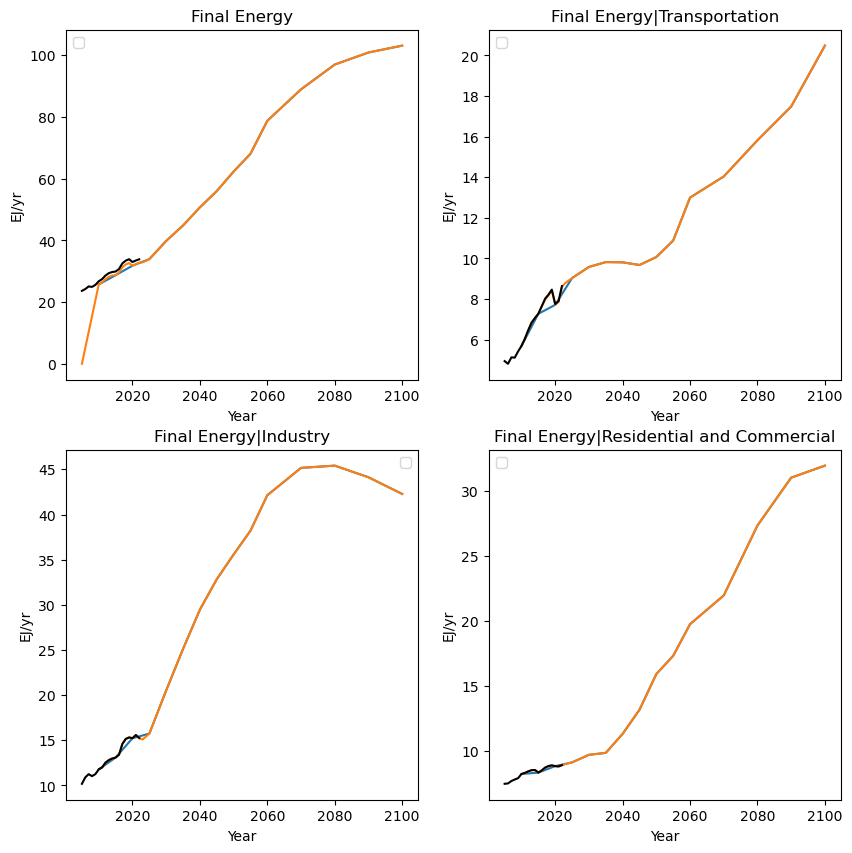

In [165]:
f, ax = plt.subplots(nrows=2,ncols=2,figsize=(10,10))
plot_region = 'OAS'

sectors = ['Final Energy','Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial']

for count, ax in enumerate(ax.ravel()):
    plt.sca(ax)
    dscale_results_agg.filter(variable=sectors[count],region=plot_region).plot(ax=plt.gca())
    input_data.filter(variable=sectors[count],region=plot_region).plot(ax=plt.gca())
    hist_agg.filter(variable=sectors[count],region=plot_region,year=range(2005,2024)).plot(ax=plt.gca(),color='k')
    ax.set_title(f'{sectors[count]}')

Look at whether Secondary Energy|Electricity is ever bigger than Final Energy

In [51]:
dscale_results.filter(variable='*Electricity+Trade',keep=False,inplace=True)

dscale_results.subtract(
    'Secondary Energy|Electricity',
    # 'Secondary Energy|Electricity|Trade',
    'Secondary Energy|Electricity|T&D losses, conversion to synthetic fuels and net exports',
    'Secondary Energy|Electricity|accounting for losses',
    append=True
)

In [52]:
tnd_losses = dscale_results.divide(
    'Final Energy|Electricity',
    'Secondary Energy|Electricity',
    'Transmission Losses'
).timeseries()

In [53]:
problem_isos = tnd_losses.loc[(tnd_losses.loc[:,2030:2060]>1).any(axis=1)].loc[isin(region=IKEA_ISOS)].pix.project('region').index

In [54]:
problem_isos# = ['BRA','MEX','ARG']

Index(['NAM', 'NGA', 'POL'], dtype='object', name='region')

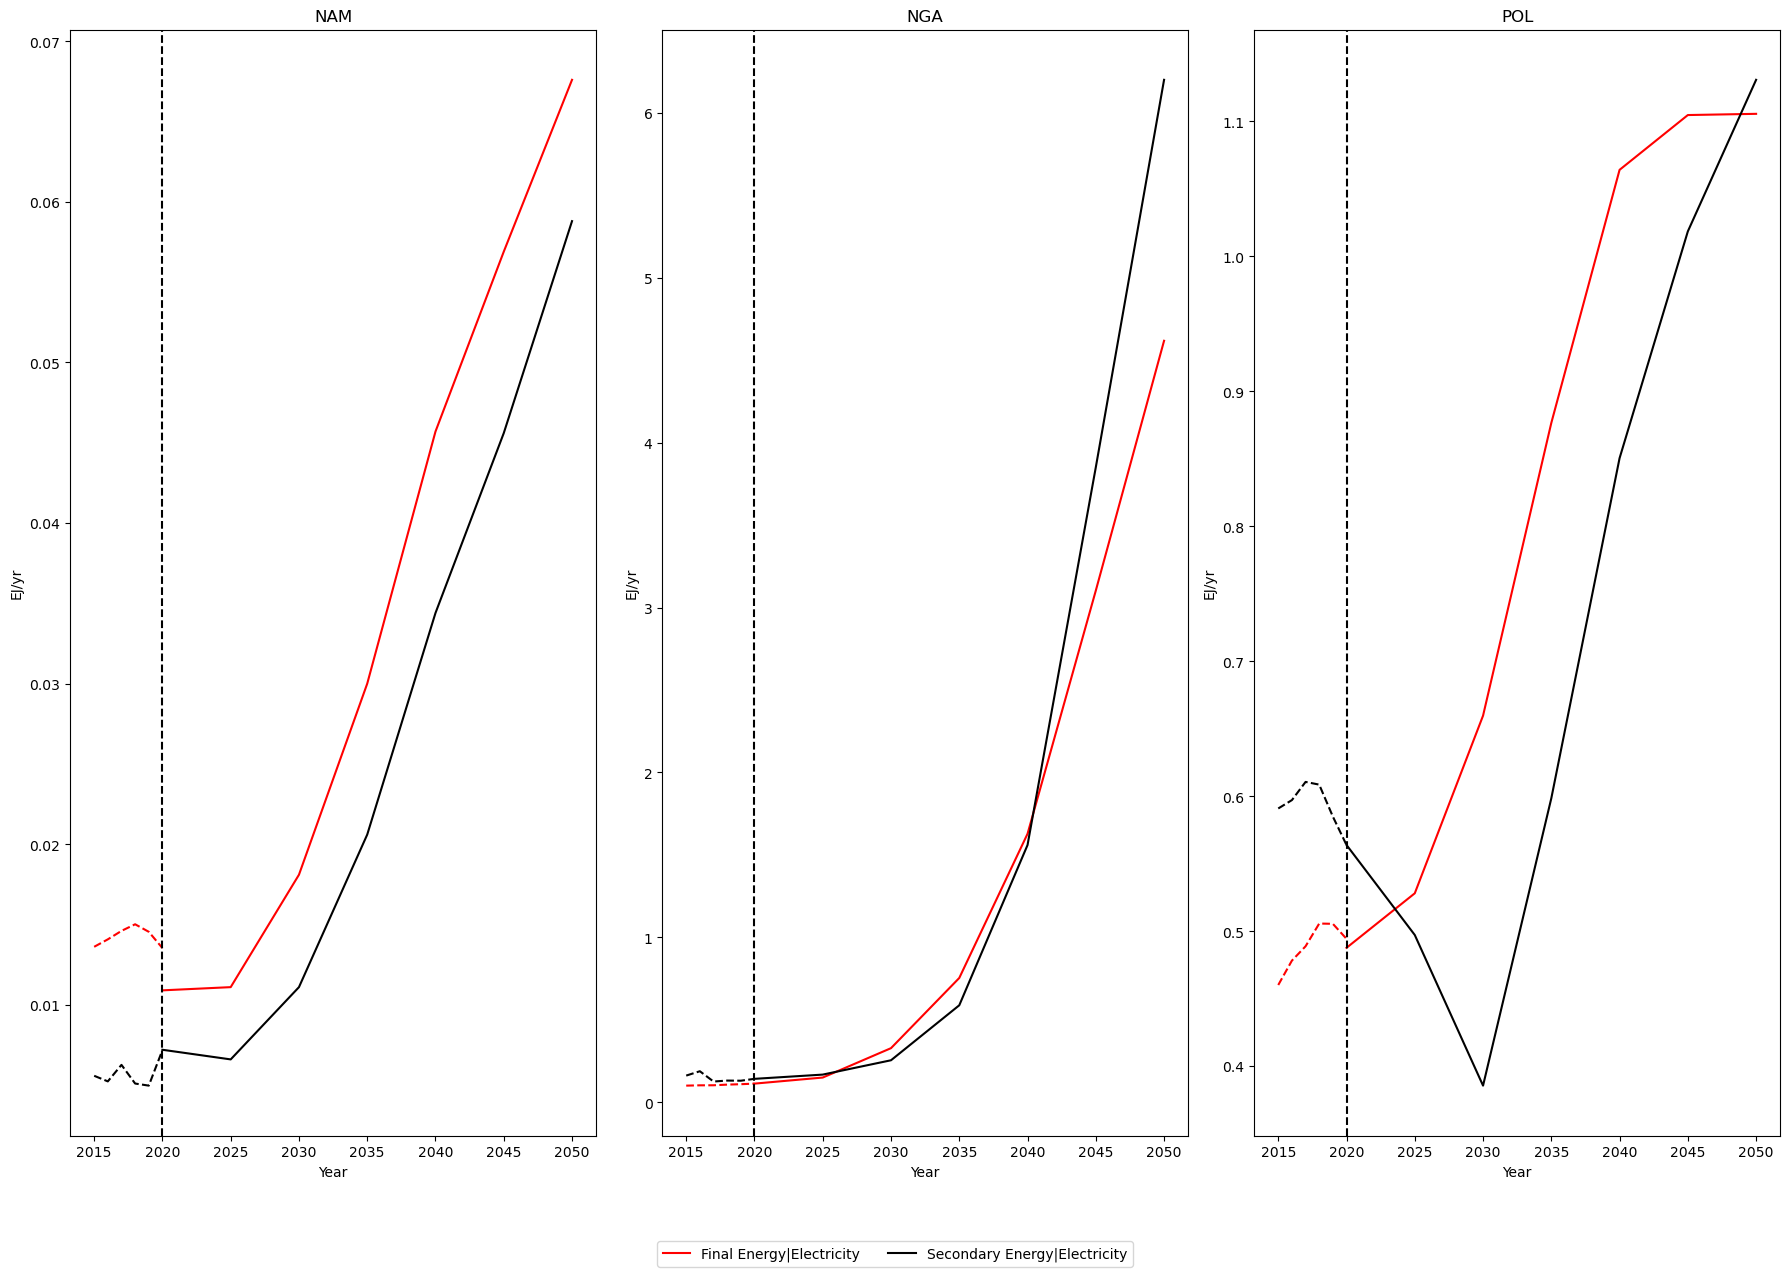

In [55]:
year_proj = [
    2020,
 2025,
 2030,
 2035,  
 2040,
 2045,
 2050,
#  2060,
#  2070,
#  2080,
#  2090,
#  2100
 ]

f, axes = plt.subplots(nrows=int(np.ceil(len(problem_isos)/3)), ncols=3, figsize=(18, 12))

color_map = {
    'Secondary Energy|Electricity':'k',
    'Final Energy|Electricity':'r'
}

pyam.run_control().update({"color": {"variable": color_map}})

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()[:len(problem_isos)]):

    dscale_results.filter(
        scenario='NPE-core',
        region=problem_isos[count],
        variable=['Final Energy|Electricity','Secondary Energy|Electricity'],
        year = year_proj
    ).plot(ax=ax,color='variable')

    hist_data_iea.filter(
        region=problem_isos[count],
        variable=['Final Energy|Electricity','Secondary Energy|Electricity'],
        year=[2015, 2016, 2017, 2018, 2019, 2020]
    ).plot(ax=ax,linestyle='--',color='variable')

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(problem_isos[count])
    ax.legend().remove()

f.legend(['Final Energy|Electricity','Secondary Energy|Electricity'],ncol=2,loc='center',bbox_to_anchor=[0.5,-0.05])

# f.suptitle('Transport sector mix',fontsize=14,fontweight='bold')
# f.legend(transport_legend_key,[l.get_label() for l in transport_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

plt.tight_layout()

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


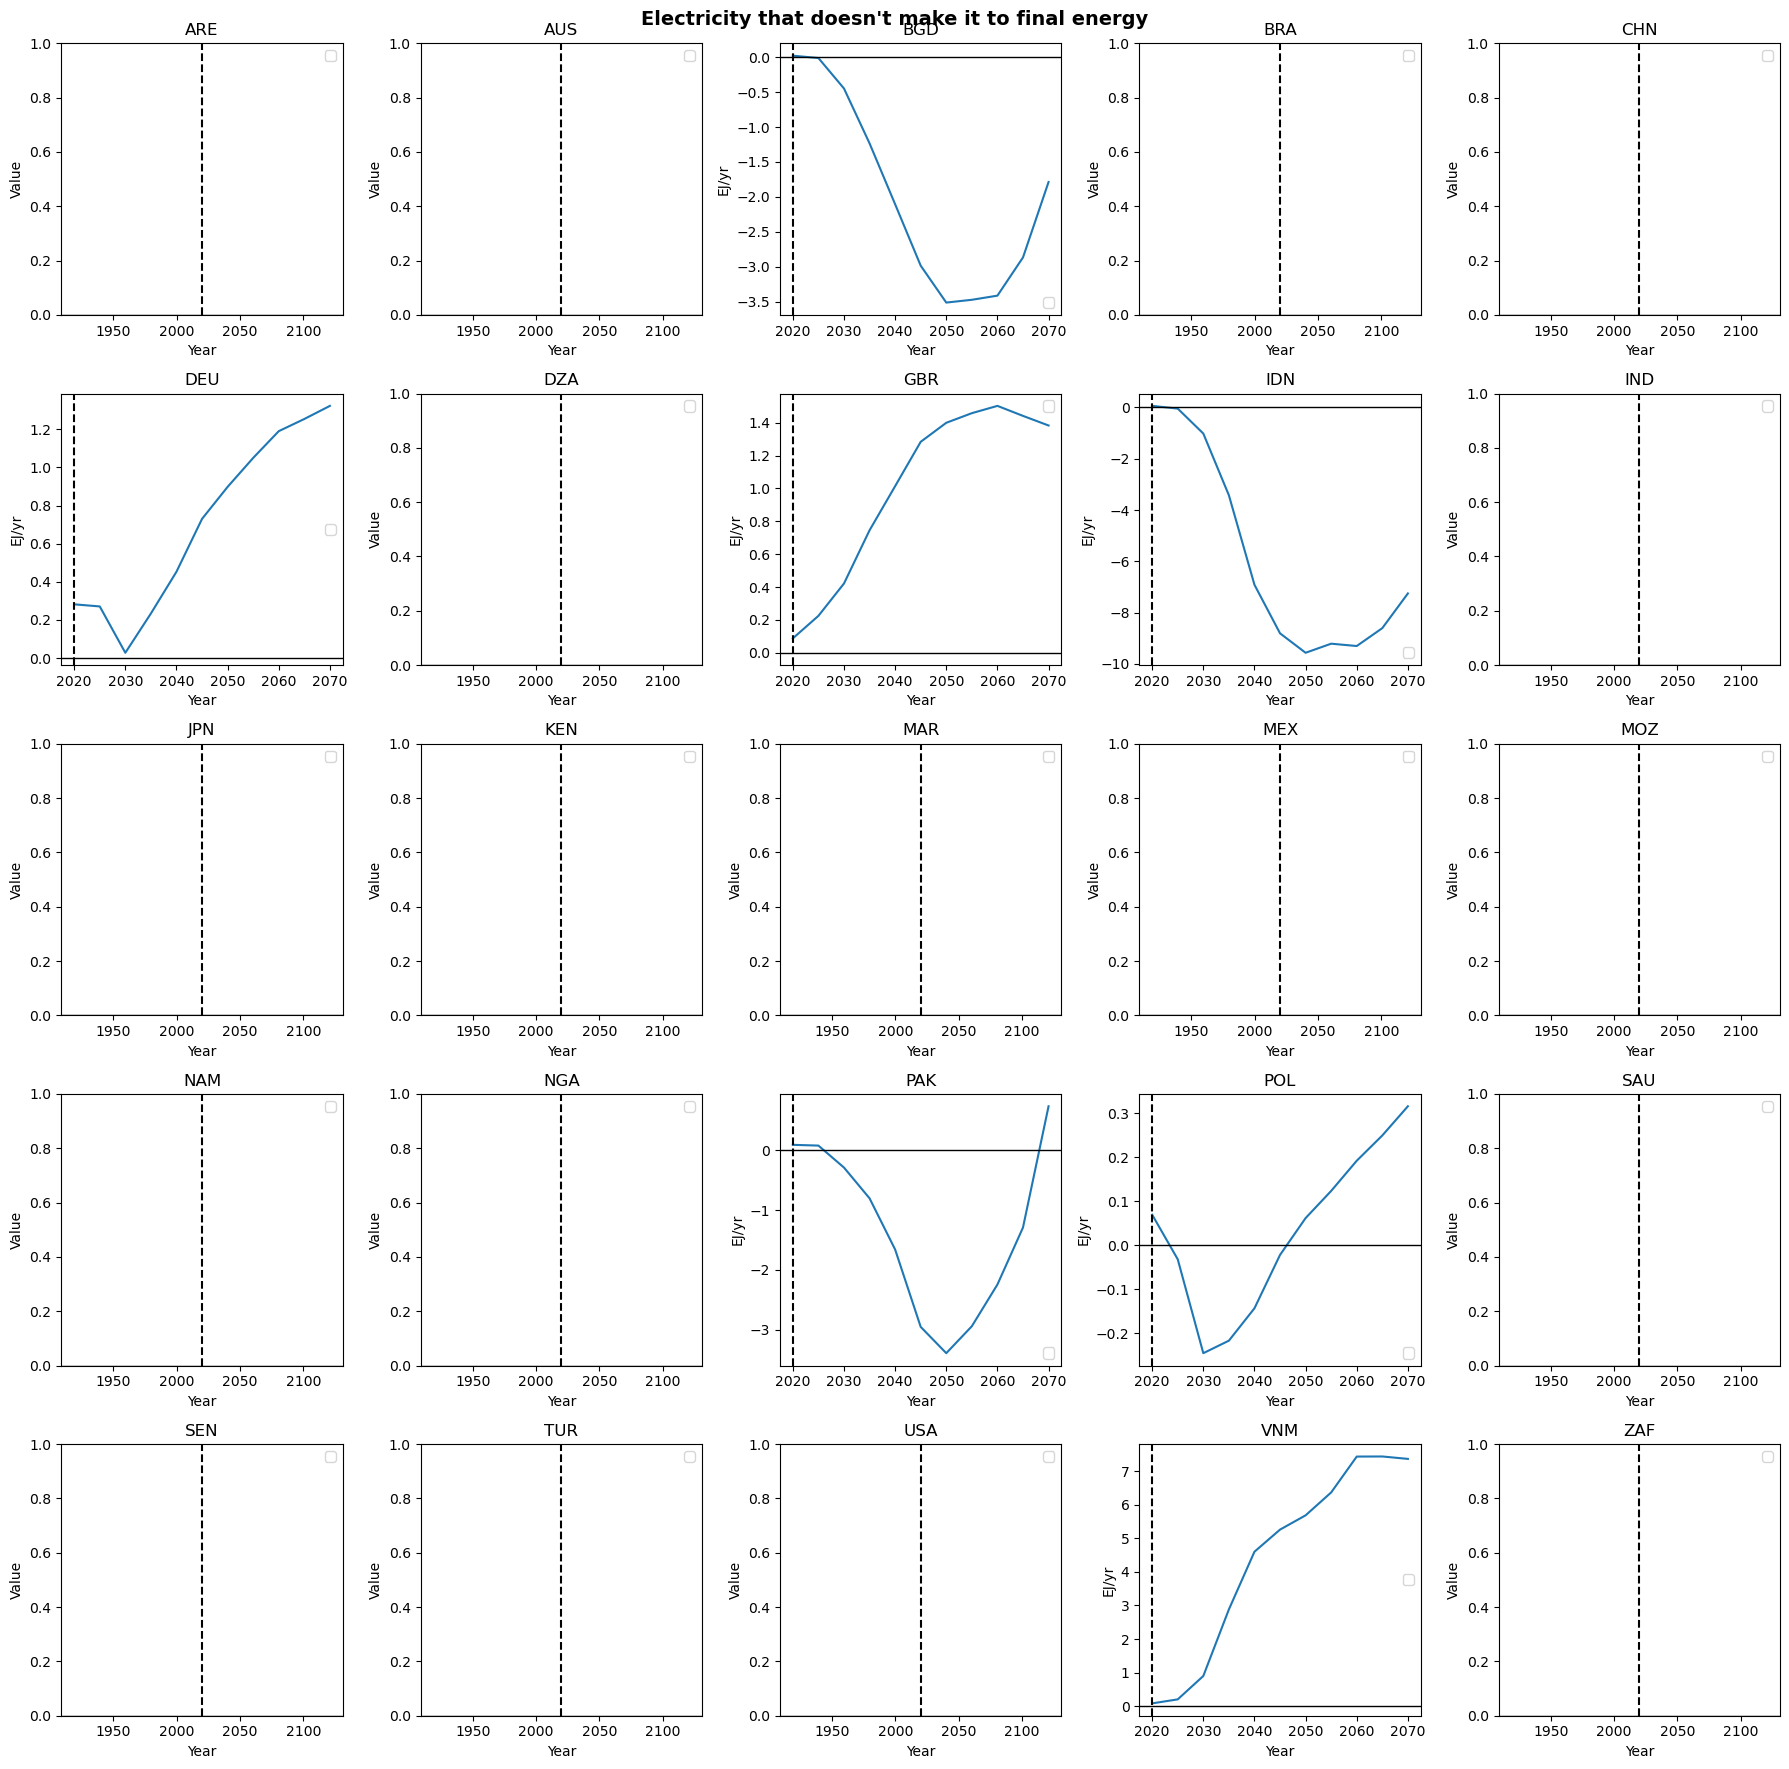

In [28]:
year_proj = range(2020,2071,5)

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable='Secondary Energy|Electricity|T&D**',
        year = year_proj
    ).plot(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.axhline(y=0,color='k',lw=1)

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle("Electricity that doesn't make it to final energy",fontsize=14,fontweight='bold')

plt.tight_layout()

## Energy mix plotting

In [21]:
transport_mix_variable = [
 'Final Energy|Transportation|Electricity',
 'Final Energy|Transportation|Gases|Biomass',
 'Final Energy|Transportation|Gases|Electricity',
 'Final Energy|Transportation|Gases|Natural Gas',
 'Final Energy|Transportation|Hydrogen',
 'Final Energy|Transportation|Liquids|Biomass',
 'Final Energy|Transportation|Liquids|Coal',
 'Final Energy|Transportation|Liquids|Electricity',
 'Final Energy|Transportation|Liquids|Oil'
 ]

In [22]:
transport_color_map = {
    'Final Energy|Transportation|Electricity': "#ffd92f",
    'Final Energy|Transportation|Gases|Biomass': "#28a441",
    'Final Energy|Transportation|Gases|Electricity': "#500e6f",
    'Final Energy|Transportation|Gases|Natural Gas': "#77797c",
    'Final Energy|Transportation|Hydrogen': "#5fa2cf",
    'Final Energy|Transportation|Liquids|Biomass': '#4ef670',
    # 'Final Energy|Transportation|Liquids|Coal': "#9F9F9F",
    'Final Energy|Transportation|Liquids|Electricity': "#941dcc",
    'Final Energy|Transportation|Liquids|Oil': "#202020"
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

transport_legend_key = []
for color in transport_color_map.keys():
    transport_legend_key.append(mpatches.Patch(label=color,color=transport_color_map[color]))


pyam.run_control().update({"color": {"variable": transport_color_map}, "hatch" : {"scenario" : hatch}})

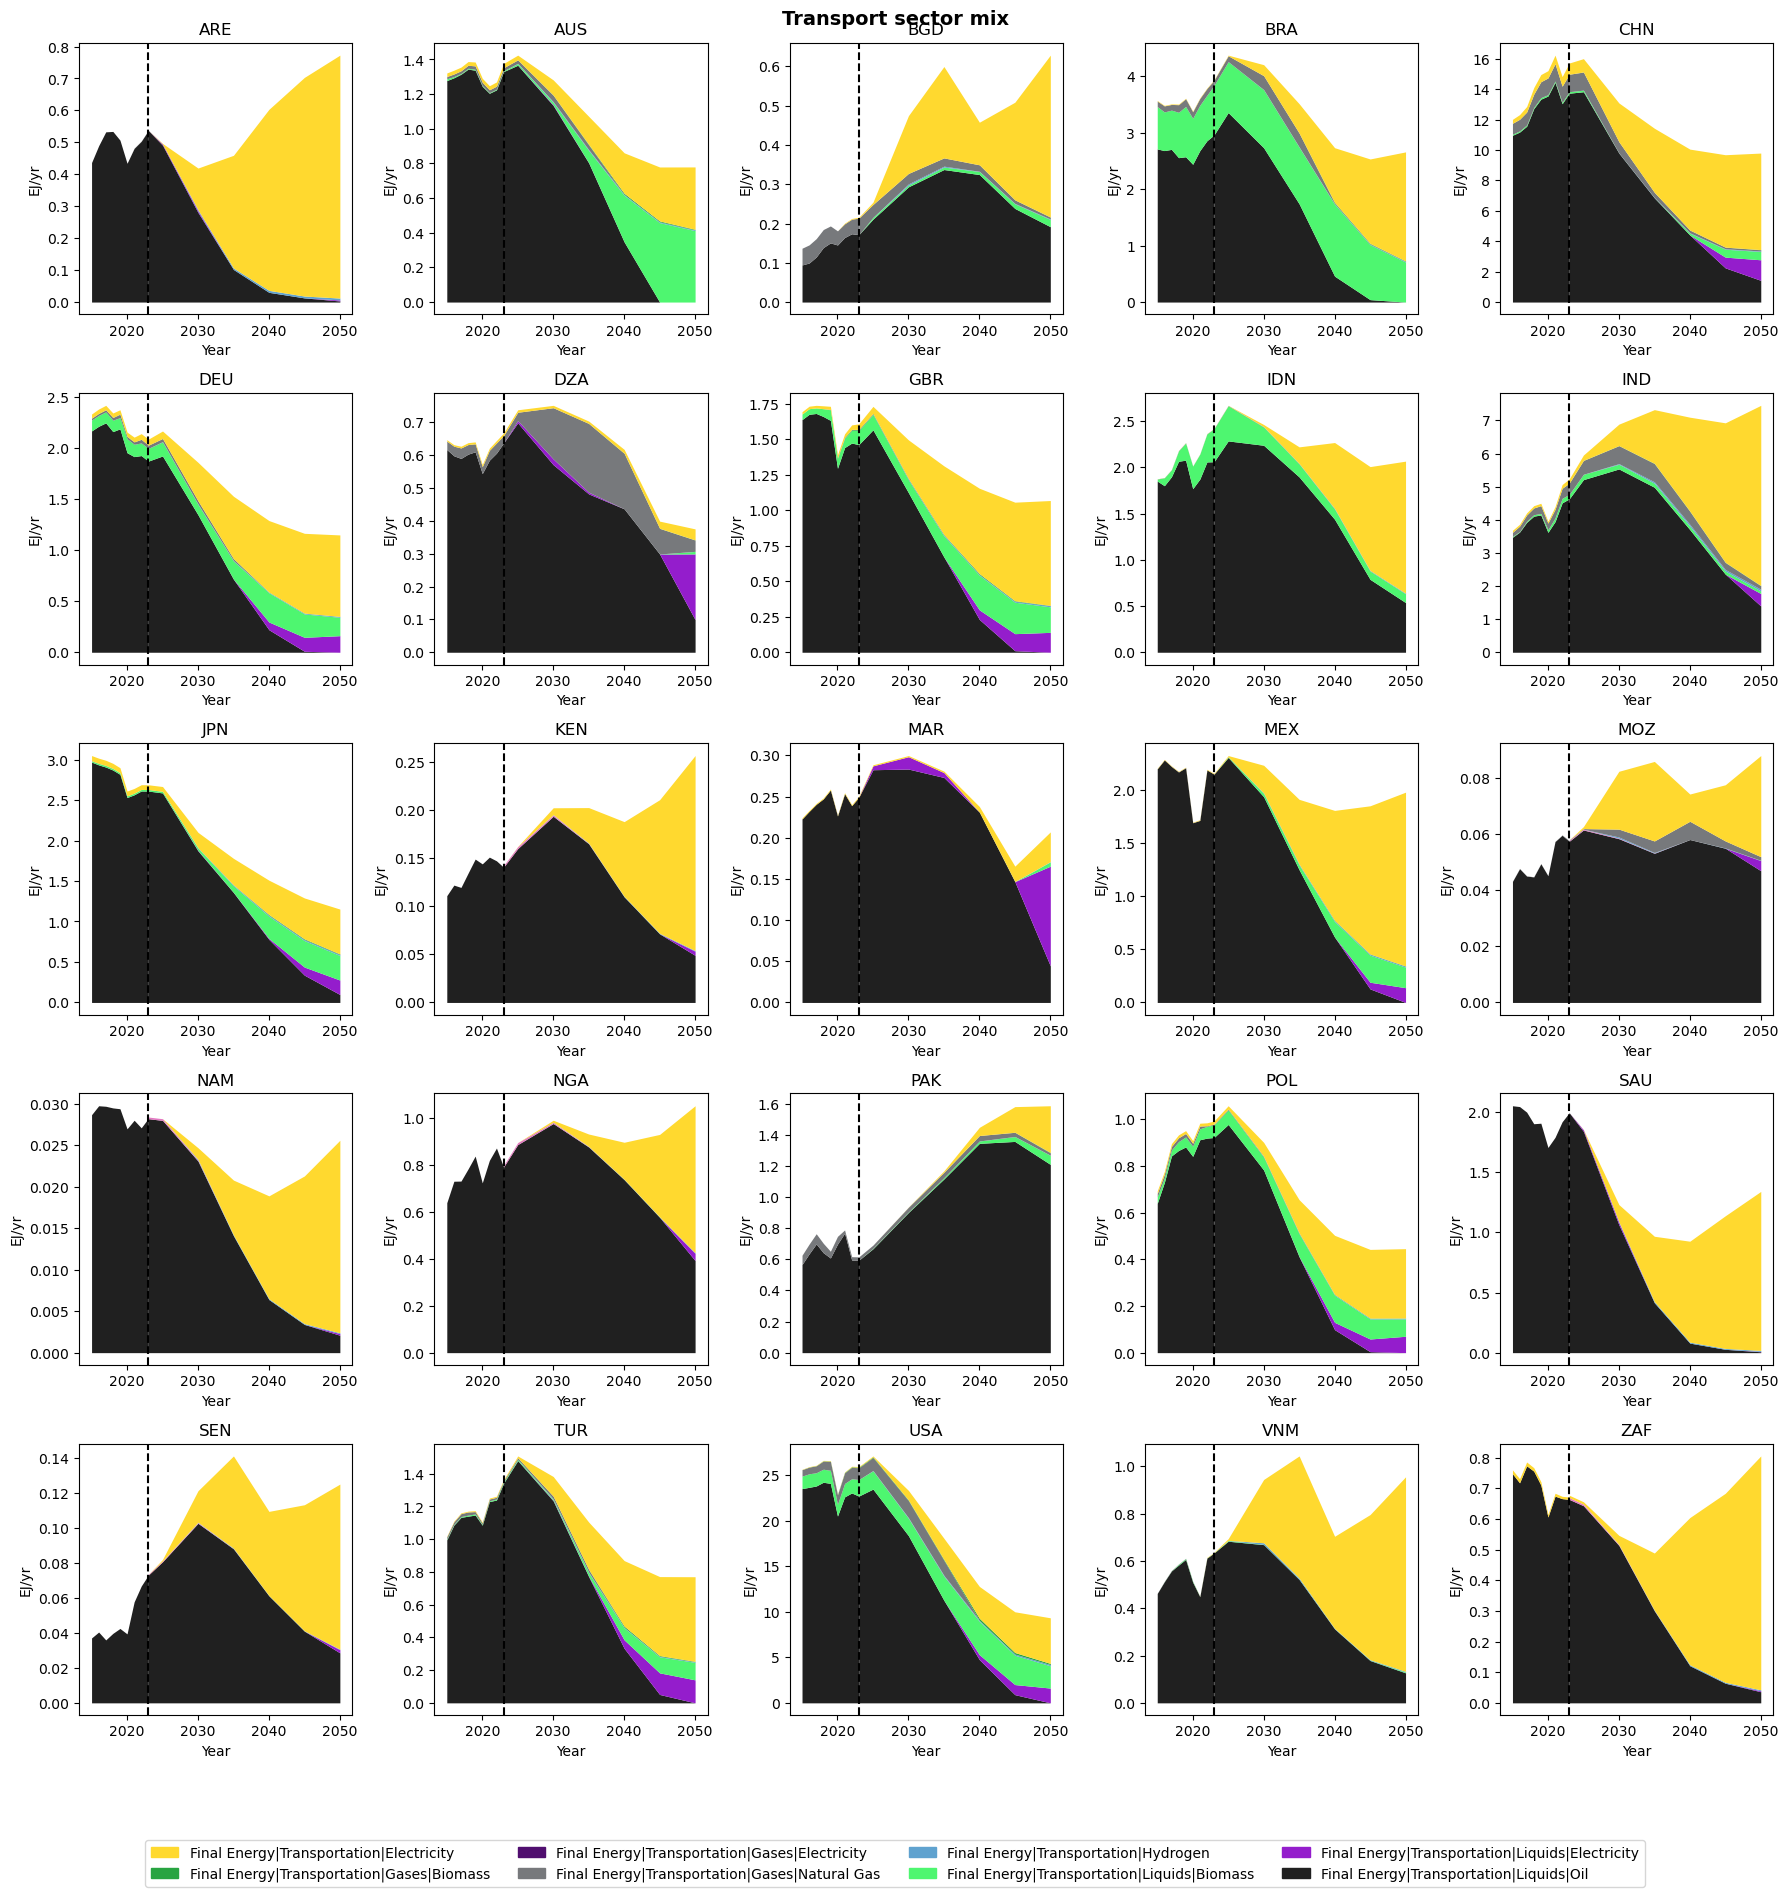

In [16]:
year_proj = [
    # 2020,
    2023,
    2025,
    2030,
    2035,
    2040,
    2045,
    2050,
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=transport_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=transport_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    ).plot.stack(ax=ax)

    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Transport sector mix',fontsize=14,fontweight='bold')
f.legend(transport_legend_key,[l.get_label() for l in transport_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

plt.tight_layout()

Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/final_energy').mkdir(parents=True,exist_ok=True)
plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/final_energy/transport_fuel_mix.png',dpi=300)


In [17]:
industry_mix_variable = [
 'Final Energy|Industry|Electricity',
 'Final Energy|Industry|Gases|Biomass',
 'Final Energy|Industry|Gases|Electricity',
 'Final Energy|Industry|Gases|Natural Gas',
 'Final Energy|Industry|Hydrogen',
 'Final Energy|Industry|Heat',
 'Final Energy|Industry|Liquids|Biomass',
 'Final Energy|Industry|Liquids|Coal',
 'Final Energy|Industry|Liquids|Electricity',
 'Final Energy|Industry|Liquids|Oil',
 'Final Energy|Industry|Solids|Biomass',
 'Final Energy|Industry|Solids|Coal'
 ]

industry_color_map = {
    'Final Energy|Industry|Electricity': "#ffd92f",
    'Final Energy|Industry|Gases|Biomass': "#28a441",
    'Final Energy|Industry|Liquids|Biomass': '#4ef670',
    'Final Energy|Industry|Solids|Biomass': "#1a5726",
    'Final Energy|Industry|Gases|Electricity': "#500e6f",
    'Final Energy|Industry|Liquids|Electricity': "#941dcc",
    'Final Energy|Industry|Hydrogen': "#5fa2cf",
    'Final Energy|Industry|Solids|Coal': "#000000",
    'Final Energy|Industry|Liquids|Oil': "#323232",
    'Final Energy|Industry|Gases|Natural Gas': "#77797c",
    'Final Energy|Industry|Heat': "#cb5202",
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

industry_legend_key = []
for color in industry_color_map.keys():
    industry_legend_key.append(mpatches.Patch(label=color,color=industry_color_map[color]))


pyam.run_control().update({"color": {"variable": industry_color_map}, "hatch" : {"scenario" : hatch}})

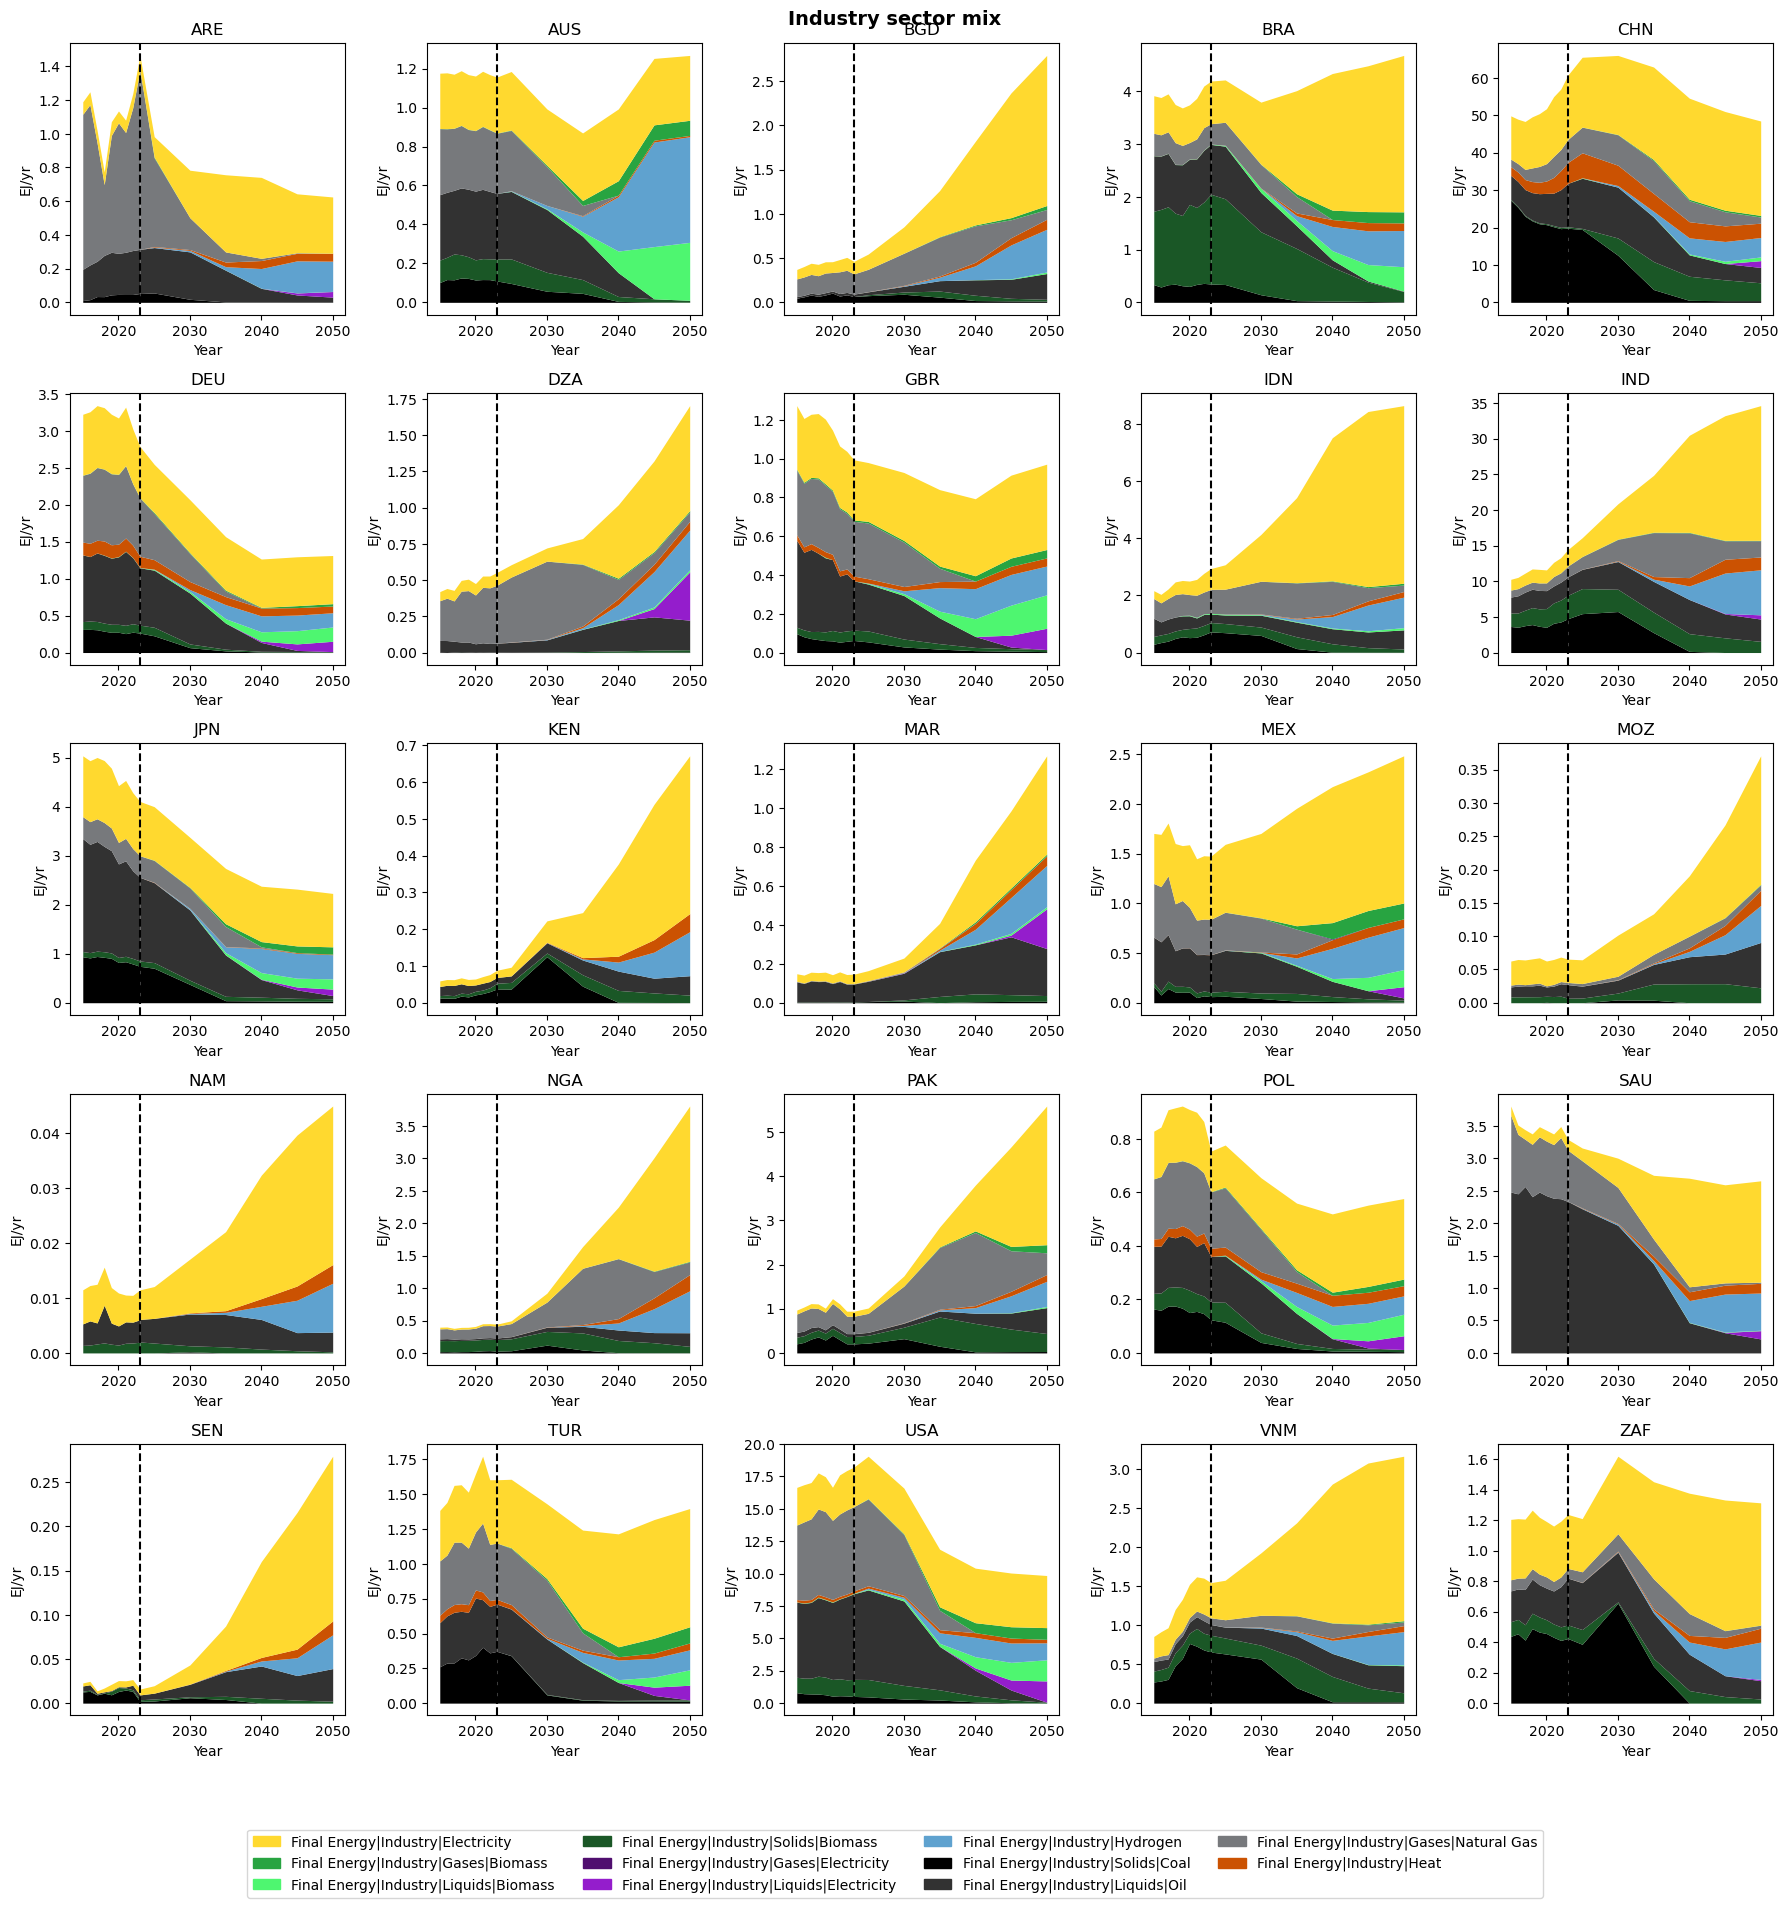

In [18]:
year_proj = [2023,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=industry_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=industry_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    ).plot.stack(ax=ax)

    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Industry sector mix',fontsize=14,fontweight='bold')
f.legend(industry_legend_key,[l.get_label() for l in industry_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

plt.tight_layout()

Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/final_energy').mkdir(parents=True,exist_ok=True)
plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/final_energy/industry_fuel_mix.png',dpi=300)


In [19]:
buildings_mix_variable = [
 'Final Energy|Residential and Commercial|Electricity',
 'Final Energy|Residential and Commercial|Gases|Biomass',
 'Final Energy|Residential and Commercial|Gases|Electricity',
 'Final Energy|Residential and Commercial|Gases|Natural Gas',
 'Final Energy|Residential and Commercial|Hydrogen',
 'Final Energy|Residential and Commercial|Liquids|Biomass',
 'Final Energy|Residential and Commercial|Liquids|Coal',
 'Final Energy|Residential and Commercial|Liquids|Electricity',
 'Final Energy|Residential and Commercial|Liquids|Oil',
 'Final Energy|Residential and CommercialSolids|Biomass',
 'Final Energy|Residential and Commercial|Solids|Coal'
 ]


buildings_color_map = {
    'Final Energy|Residential and Commercial|Electricity': "#ffd92f",
    'Final Energy|Residential and Commercial|Gases|Biomass': "#28a441",
    'Final Energy|Residential and Commercial|Liquids|Biomass': '#4ef670',
    'Final Energy|Residential and Commercial|Solids|Biomass': "#1a5726",
    'Final Energy|Residential and Commercial|Gases|Electricity': "#500e6f",
    'Final Energy|Residential and Commercial|Liquids|Electricity': "#941dcc",
    'Final Energy|Residential and Commercial|Hydrogen': "#5fa2cf",
    'Final Energy|Residential and Commercial|Solids|Coal': "#000000",
    'Final Energy|Residential and Commercial|Liquids|Oil': "#575757",
    'Final Energy|Residential and Commercial|Gases|Natural Gas': "#b2b2b2",
    'Final Energy|Residential and Commercial|Heat': "#cb5202",
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

buildings_legend_key = []
for color in buildings_color_map.keys():
    buildings_legend_key.append(mpatches.Patch(label=color,color=buildings_color_map[color]))


pyam.run_control().update({"color": {"variable": buildings_color_map}, "hatch" : {"scenario" : hatch}})

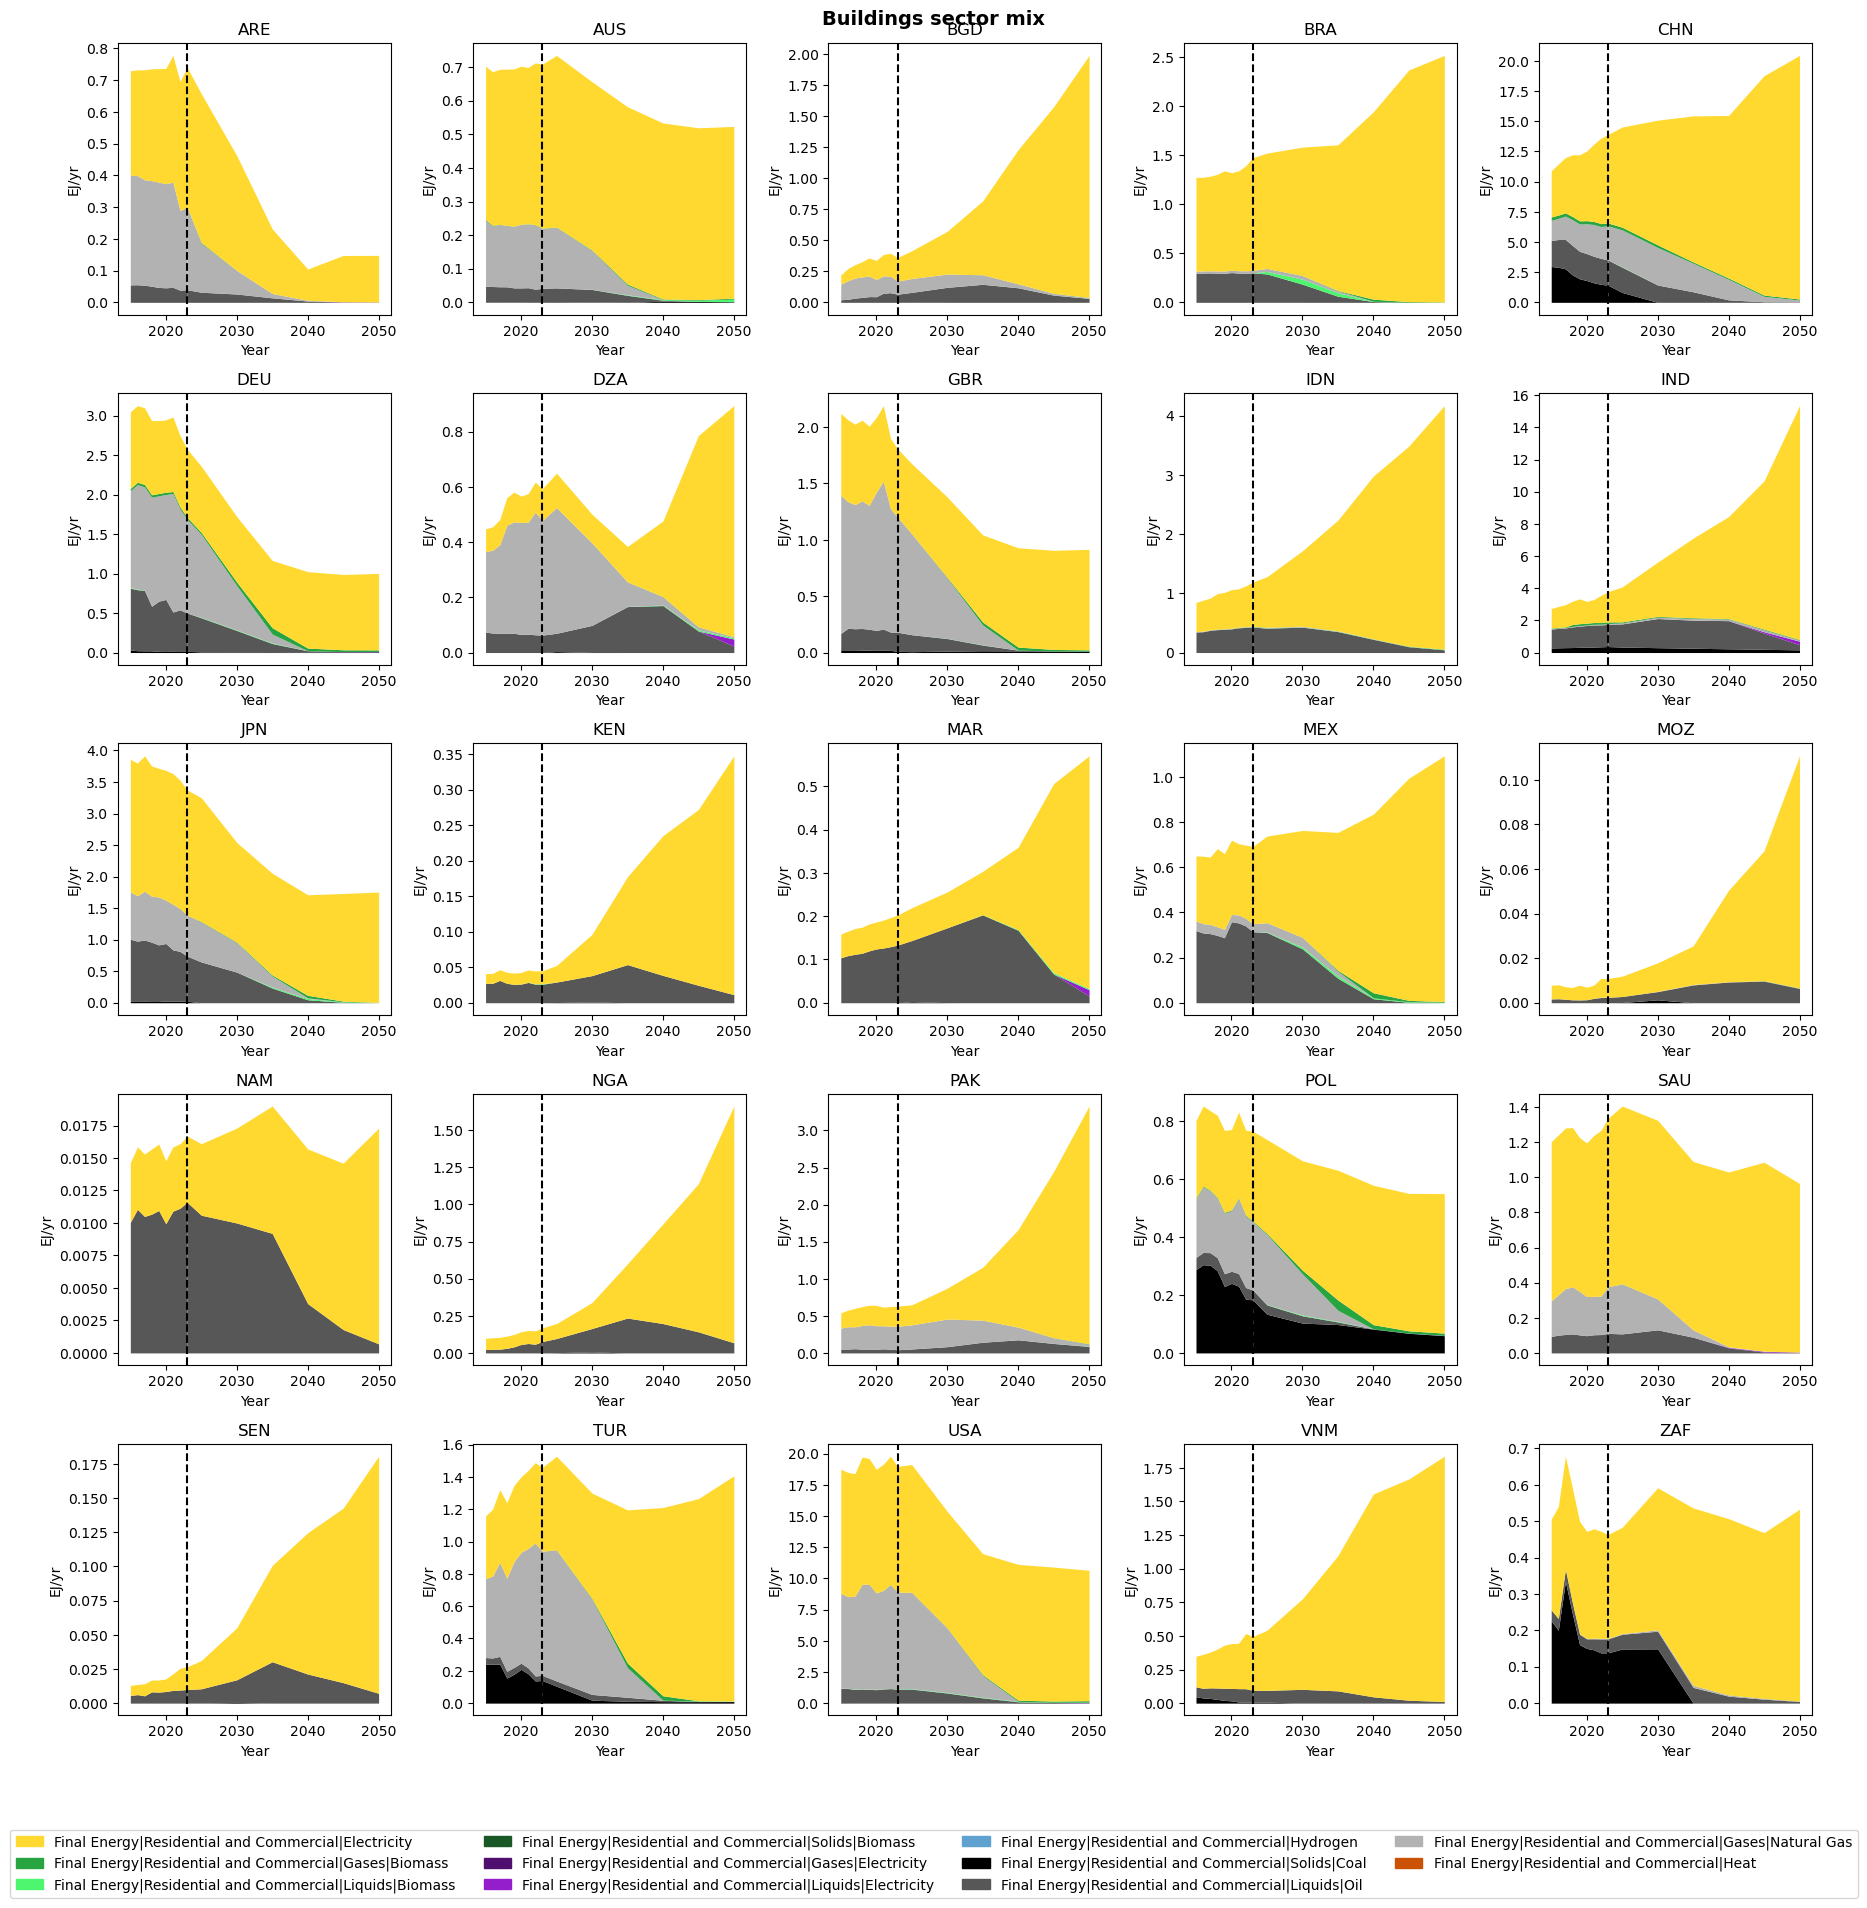

In [20]:
year_proj = [2023,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=buildings_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=buildings_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    ).plot.stack(ax=ax)

    ax.axvline(x=2023, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Buildings sector mix',fontsize=14,fontweight='bold')
f.legend(buildings_legend_key,[l.get_label() for l in buildings_legend_key],ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()


Path(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/final_energy').mkdir(parents=True,exist_ok=True)
plt.savefig(f'../results/7_Diagnostics/{dscale_project}/{dscale_suffix}/final_energy/building_fuel_mix.png',dpi=300)
